# Online Retail II — Data Inspection

This notebook inspects the raw Online Retail II dataset, verifies its structure, and identifies initial data-quality considerations before cleaning.



In [1]:
import sys
from pathlib import Path

import pandas as pd

print("Python executable:", sys.executable)
print("Pandas version:", pd.__version__)

Python executable: c:\Users\hp\anaconda3\envs\retail_analytics\python.exe
Pandas version: 3.0.5


In [2]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = (
    project_root
    / "data"
    / "raw"
    / "online_retail_II.xlsx"
)

print("Current working directory:", Path.cwd())
print("Project root:", project_root)
print("Dataset path:", data_path)
print("Dataset exists:", data_path.exists())

Current working directory: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics\notebooks
Project root: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics
Dataset path: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics\data\raw\online_retail_II.xlsx
Dataset exists: True


In [3]:
excel_file = pd.ExcelFile(data_path)

print("Worksheet names:")
print(excel_file.sheet_names)

Worksheet names:
['Year 2009-2010', 'Year 2010-2011']


In [4]:
for sheet_name in excel_file.sheet_names:
    sample = pd.read_excel(
        data_path,
        sheet_name=sheet_name,
        nrows=5
    )

    print(f"\nWorksheet: {sheet_name}")
    print("Columns:", sample.columns.tolist())
    print("Data types:")
    print(sample.dtypes)

    display(sample)


Worksheet: Year 2009-2010
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Data types:
Invoice                 int64
StockCode              object
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             int64
Country                   str
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom



Worksheet: Year 2010-2011
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Data types:
Invoice                 int64
StockCode              object
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             int64
Country                   str
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## Load and Combine the Worksheets

In [5]:
sheet_data = pd.read_excel(
    data_path,
    sheet_name=excel_file.sheet_names
)

for sheet_name, dataframe in sheet_data.items():
    print(f"{sheet_name}: {dataframe.shape}")

retail_raw = pd.concat(
    [
        dataframe.assign(SourceYear=sheet_name)
        for sheet_name, dataframe in sheet_data.items()
    ],
    ignore_index=True
)

memory_mb = retail_raw.memory_usage(deep=True).sum() / (1024 ** 2)

print("\nCombined dataset shape:", retail_raw.shape)
print(f"Memory usage: {memory_mb:.2f} MB")

display(retail_raw.head())

Year 2009-2010: (525461, 8)
Year 2010-2011: (541910, 8)

Combined dataset shape: (1067371, 9)
Memory usage: 338.76 MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceYear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010


## Initial Data Quality Profile

In [6]:
retail_raw.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
 8   SourceYear   1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(2)
memory usage: 73.3+ MB


In [7]:
missing_summary = pd.DataFrame({
    "Missing Count": retail_raw.isna().sum(),
    "Missing Percentage": (
        retail_raw.isna().mean() * 100
    ).round(2)
}).sort_values(
    by="Missing Count",
    ascending=False
)

duplicate_count = retail_raw.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)
print("Minimum invoice date:", retail_raw["InvoiceDate"].min())
print("Maximum invoice date:", retail_raw["InvoiceDate"].max())
print("Unique invoices:", retail_raw["Invoice"].nunique())
print("Unique stock codes:", retail_raw["StockCode"].nunique())
print("Unique customers:", retail_raw["Customer ID"].nunique())
print("Unique countries:", retail_raw["Country"].nunique())

display(missing_summary)


Exact duplicate rows: 12133
Minimum invoice date: 2009-12-01 07:45:00
Maximum invoice date: 2011-12-09 12:50:00
Unique invoices: 53628
Unique stock codes: 5305
Unique customers: 5942
Unique countries: 43


,Missing Count,Missing Percentage
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
Quantity,0,0.00
StockCode,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00
SourceYear,0,0.00


## Business-Rule Checks

This section examines cancellations, invalid quantities, invalid prices, missing identifiers, and duplicate transactions before defining the cleaning rules.

In [8]:
invoice_text = retail_raw["Invoice"].astype("string")

cancelled_mask = invoice_text.str.upper().str.startswith(
    "C",
    na=False
)

quality_checks = pd.DataFrame({
    "Check": [
        "Exact duplicate rows",
        "Cancelled transaction rows",
        "Missing customer IDs",
        "Missing descriptions",
        "Negative quantities",
        "Zero quantities",
        "Negative prices",
        "Zero prices"
    ],
    "Row Count": [
        retail_raw.duplicated().sum(),
        cancelled_mask.sum(),
        retail_raw["Customer ID"].isna().sum(),
        retail_raw["Description"].isna().sum(),
        retail_raw["Quantity"].lt(0).sum(),
        retail_raw["Quantity"].eq(0).sum(),
        retail_raw["Price"].lt(0).sum(),
        retail_raw["Price"].eq(0).sum()
    ]
})

quality_checks["Percentage of Rows"] = (
    quality_checks["Row Count"]
    / len(retail_raw)
    * 100
).round(2)

print(
    "Unique cancelled invoices:",
    retail_raw.loc[cancelled_mask, "Invoice"].nunique()
)

display(quality_checks)

Unique cancelled invoices: 8292


,Check,Row Count,Percentage of Rows
0,Exact duplicate rows,12133,1.14
1,Cancelled transaction rows,19494,1.83
2,Missing customer IDs,243007,22.77
3,Missing descriptions,4382,0.41
4,Negative quantities,22950,2.15
5,Zero quantities,0,0.00
6,Negative prices,5,0.00
7,Zero prices,6202,0.58


In [9]:
numeric_summary = retail_raw[
    ["Quantity", "Price"]
].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T

display(numeric_summary)

,count,mean,std,min,1%,25%,50%,75%,99%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,-3.00,1.00,3.0,10.00,100.0,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,0.21,1.25,2.1,4.15,18.0,38970.0


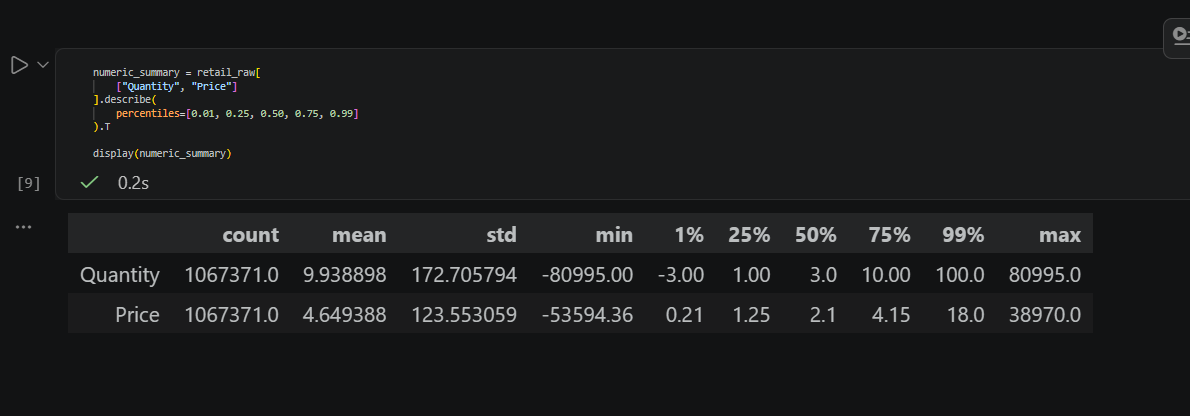

## Investigation of Cancellations and Transaction Anomalies

In [10]:
analysis_columns = [
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "Customer ID",
    "Country",
    "SourceYear"
]

cancellation_quantity_table = pd.crosstab(
    cancelled_mask,
    retail_raw["Quantity"].lt(0),
    rownames=["Invoice Starts With C"],
    colnames=["Quantity Is Negative"]
)

negative_non_cancelled = retail_raw.loc[
    retail_raw["Quantity"].lt(0) & ~cancelled_mask
]

negative_price_rows = retail_raw.loc[
    retail_raw["Price"].lt(0),
    analysis_columns
]

print(
    "Negative-quantity rows without a cancelled invoice:",
    len(negative_non_cancelled)
)

display(cancellation_quantity_table)

print("\nNegative-price transactions:")
display(negative_price_rows)

print("\nSample of negative quantities without a cancelled invoice:")
display(
    negative_non_cancelled[analysis_columns].head(20)
)

Negative-quantity rows without a cancelled invoice: 3457


Quantity Is Negative,False,True
Invoice Starts With C,,
False,1044420,3457
True,1,19493



Negative-price transactions:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceYear
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,Year 2009-2010
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,Year 2009-2010
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,Year 2009-2010
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,Year 2010-2011
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,Year 2010-2011



Sample of negative quantities without a cancelled invoice:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceYear
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,Year 2009-2010
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,Year 2009-2010
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,Year 2009-2010
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,Year 2009-2010
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,Year 2009-2010
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom,Year 2009-2010
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom,Year 2009-2010
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom,Year 2009-2010
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom,Year 2009-2010
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom,Year 2009-2010


In [11]:
zero_price_summary = (
    retail_raw.loc[retail_raw["Price"].eq(0)]
    .groupby(
        ["StockCode", "Description"],
        dropna=False
    )
    .agg(
        Row_Count=("Invoice", "size"),
        Net_Quantity=("Quantity", "sum")
    )
    .sort_values(
        by="Row_Count",
        ascending=False
    )
    .head(20)
)

print("Most common zero-price products or adjustments:")
display(zero_price_summary)

Most common zero-price products or adjustments:


,,Row_Count,Net_Quantity
StockCode,Description,,
21116,OWL DOORSTOP,15,28
22139,NaN,12,63
84990,NaN,12,68
46000M,POLYESTER FILLER PAD 45x45cm,12,1688
35965,NaN,11,13
79321,NaN,11,-51
22624,IVORY KITCHEN SCALES,10,36
46000S,POLYESTER FILLER PAD 40x40cm,10,1790
22676,FRENCH BLUE METAL DOOR SIGN 1,10,29


## Inspection Conclusions and Cleaning Decisions

The raw dataset contains 1,067,371 transaction rows covering December 2009 through December 2011.

### Identified data-quality conditions

- 12,133 exact duplicate rows were detected.
- 243,007 rows have missing customer IDs.
- 4,382 rows have missing product descriptions.
- 19,494 rows belong to cancelled invoices.
- 3,457 negative-quantity rows do not belong to cancelled invoices and primarily represent stock adjustments, losses, damages, or corrections.
- Five negative-price rows represent bad-debt accounting adjustments.
- 6,202 rows have a zero price and include stock adjustments and possible non-revenue items.
- Extreme quantity and price values require separate validation and will not be removed solely because they are statistical outliers.

### Cleaning strategy

1. Remove exact duplicate records while preserving the original raw dataset.
2. Standardize column names, text values, and data types.
3. Classify transactions as Sale, Cancellation, Stock Adjustment, Accounting Adjustment, or Zero-Price Transaction.
4. Use only positive-quantity, positive-price, non-cancelled transactions for sales KPIs.
5. Retain sales with missing customer IDs for overall revenue and product analysis.
6. Exclude missing customer IDs only from customer-level analysis, RFM segmentation, and cohort retention.
7. Preserve cancelled and adjustment records in separate analytical tables for auditability.
8. Exclude missing product descriptions from GenAI product classification.
9. Avoid interpreting cancellation value as confirmed financial loss or refunded revenue unless the cancellation can be matched to an original purchase.